# Health Insurance Cost Prediction Using XGBoost

## Objective
Build a machine learning model to predict medical insurance charges based on customer demographics and health factors.

The project includes:
- Exploratory Data Analysis
- Feature Engineering
- XGBoost Regression
- Model Evaluation
- SHAP Explainability

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mirichoi0218/insurance/insurance.csv


## 1. Load Dataset

The dataset contains demographic and health information used to predict annual medical charges.

In [6]:
import pandas as pd
df = pd.read_csv('/kaggle/input/datasets/mirichoi0218/insurance/insurance.csv')
print(df.head())
print(f"Shape: {df.shape}")

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
Shape: (1338, 7)


## 2. Exploratory Data Analysis (EDA)

Investigate:
- Dataset structure
- Missing values
- Feature distributions
- Relationships between features and insurance charges

In [5]:
# Check for missing values
print(df.isnull().sum())

# See basic statistics
print(df.describe())

# Understand the columns
print(df.info())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    133

## 3. Data Visualisation

Analyse:
- Distribution of numerical features
- Correlation between variables
- Impact of smoking status, age, and BMI on charges

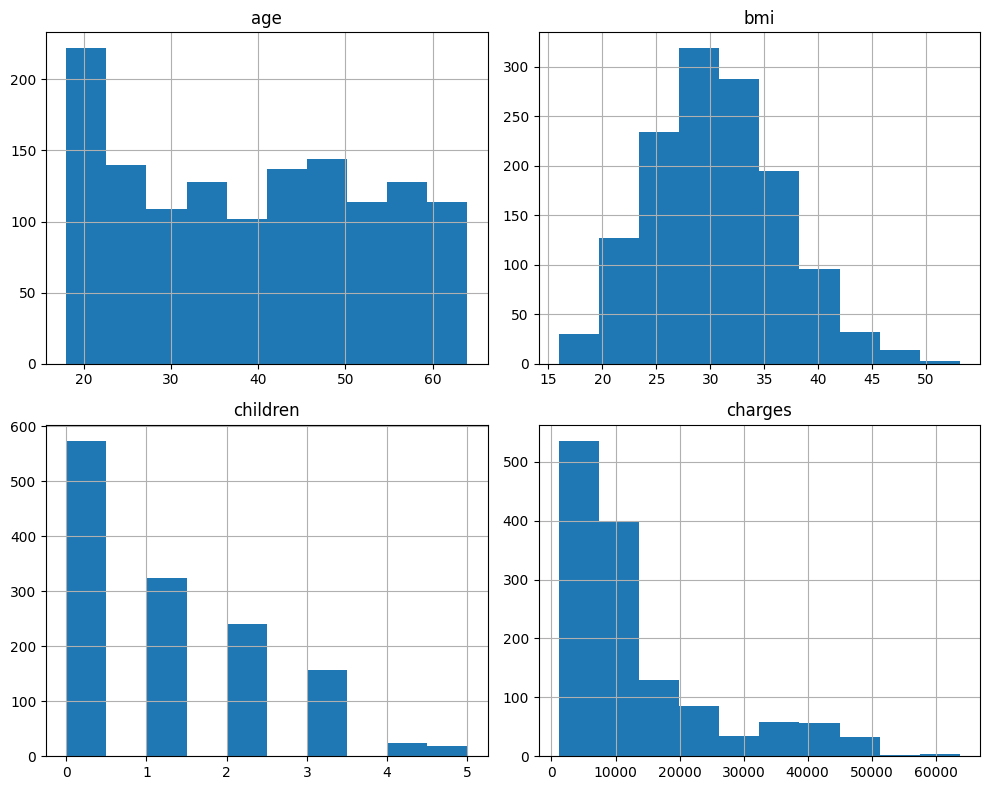

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

df.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

**Distribution of Changes(Target)**

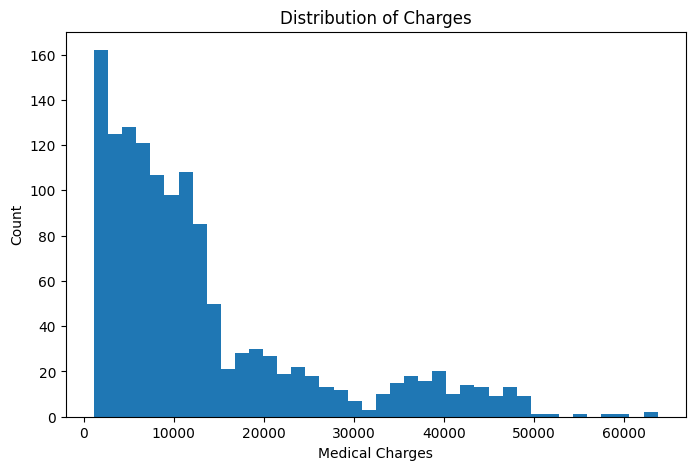

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["charges"],bins=40)
plt.xlabel("Medical Charges")
plt.ylabel("Count")
plt.title("Distribution of Charges")
plt.show()

**Corelation Matrix (Numeric Variable)**

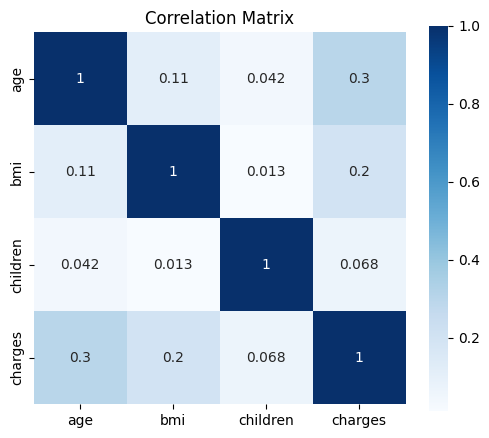

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="Blues",
           square=True)
plt.title("Correlation Matrix")
plt.show()

**Charges by Smokers**

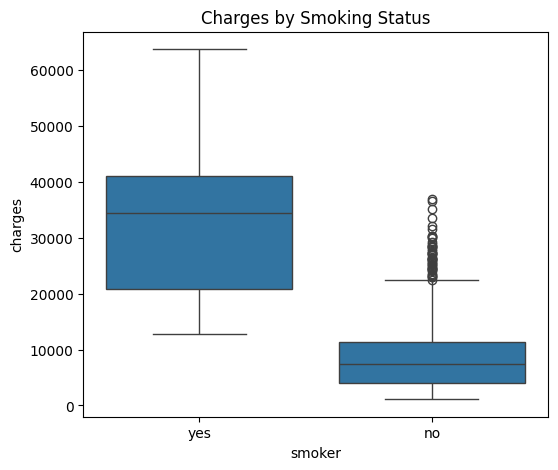

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.boxplot(x="smoker", y="charges", data=df)
plt.title("Charges by Smoking Status")
plt.show()

**Charges By AGE**

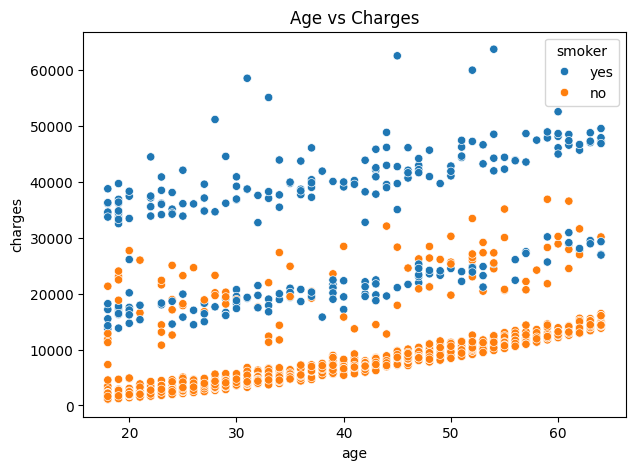

In [23]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x="age",
    y="charges",
    hue="smoker"
)
plt.title("Age vs Charges")
plt.show()

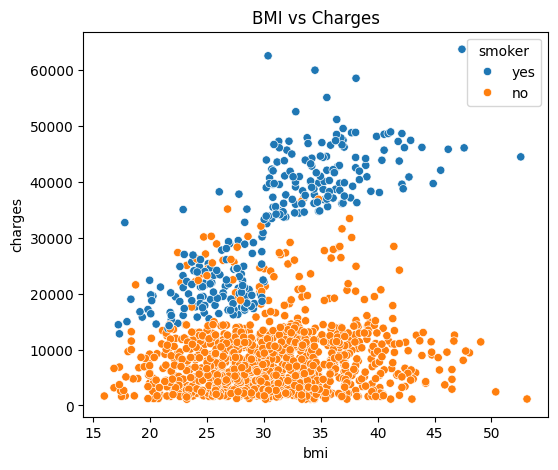

In [33]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker")
plt.title("BMI vs Charges")
plt.show()

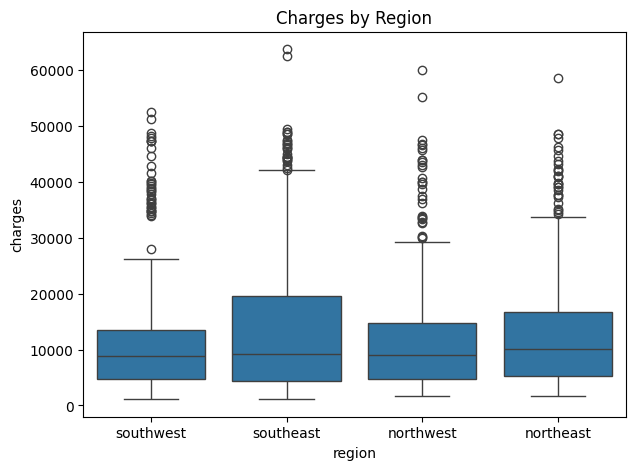

In [34]:
plt.figure(figsize=(7,5))
sns.boxplot(
    x="region",
    y="charges",
    data=df
)
plt.title("Charges by Region")
plt.show()

In [39]:
df.select_dtypes(include="object").columns

Index(['sex', 'smoker', 'region'], dtype='object')

## 4. Data Preprocessing

Categorical variables are transformed using OneHotEncoder because features such as sex, smoking status, and region have no natural numerical ordering.

In [44]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = ["sex", "smoker", "region"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ],
    remainder="passthrough"
)
X = df.drop("charges", axis=1)
y = df["charges"]

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [50]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

In [51]:
X_train_encoded.shape

(1070, 8)

In [52]:
X_test_encoded.shape

(268, 8)

In [53]:
preprocessor.get_feature_names_out()

array(['cat__sex_male', 'cat__smoker_yes', 'cat__region_northwest',
       'cat__region_southeast', 'cat__region_southwest', 'remainder__age',
       'remainder__bmi', 'remainder__children'], dtype=object)

## 5. XGBoost Regression Model

Train an XGBoost regression model to predict medical insurance charges.

In [72]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)



In [73]:
model.fit(
    X_train_encoded,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

## 6. Model Evaluation

Evaluate performance using:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² Score

In [75]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

predictions = model.predict(X_test_encoded)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 2452.9937787771687
RMSE: 4236.269939812778
R2: 0.884404962085553


In [83]:
import pandas as pd

sample = pd.DataFrame({
    "age": [30],
    "sex": ["male"],
    "bmi": [28],
    "children": [0],
    "smoker": ["yes"],
    "region": ["northeast"]
})

sample_encoded = preprocessor.transform(sample)

prediction = model.predict(sample_encoded)

print(f"Predicted annual medical charges: £{prediction[0]:,.2f}")

Predicted annual medical charges: £19,028.79


In [84]:
import pandas as pd

sample = pd.DataFrame({
    "age": [30],
    "sex": ["male"],
    "bmi": [28],
    "children": [0],
    "smoker": ["no"],
    "region": ["northeast"]
})

sample_encoded = preprocessor.transform(sample)

prediction = model.predict(sample_encoded)

print(f"Predicted annual medical charges: £{prediction[0]:,.2f}")

Predicted annual medical charges: £4,761.88


## 7. Feature Importance Analysis

Analyse which features contribute most to insurance cost predictions.

<Figure size 800x500 with 0 Axes>

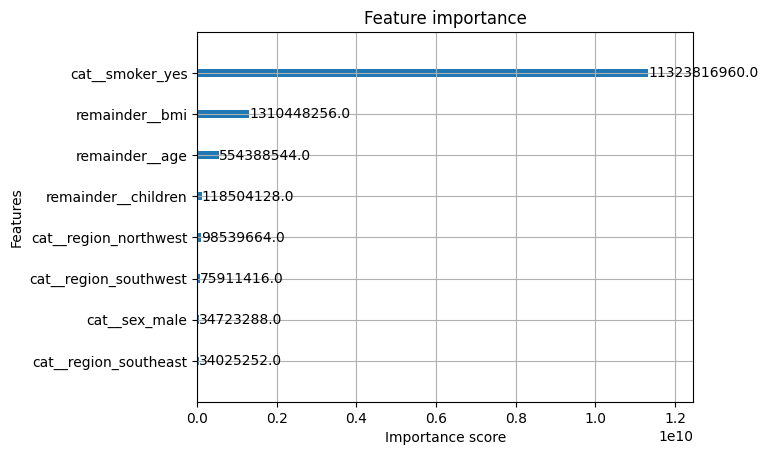

In [100]:
model.get_booster().feature_names = list(feature_names)
plt.figure(figsize=(8,5))

plot_importance(
    model,
    importance_type="gain"
)

plt.show()

## 8. Model Explainability with SHAP

SHAP is used to explain individual predictions and identify the main drivers behind insurance cost predictions.

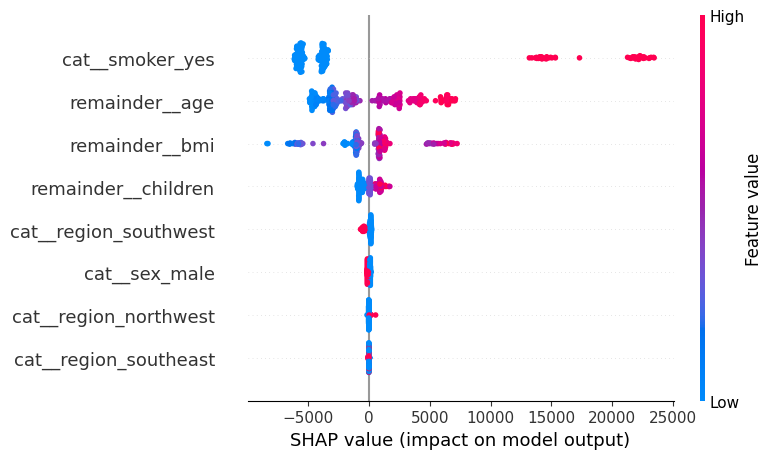

In [98]:
import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test_encoded)

shap.summary_plot(
    shap_values,
    X_test_encoded,
    feature_names=preprocessor.get_feature_names_out()
)

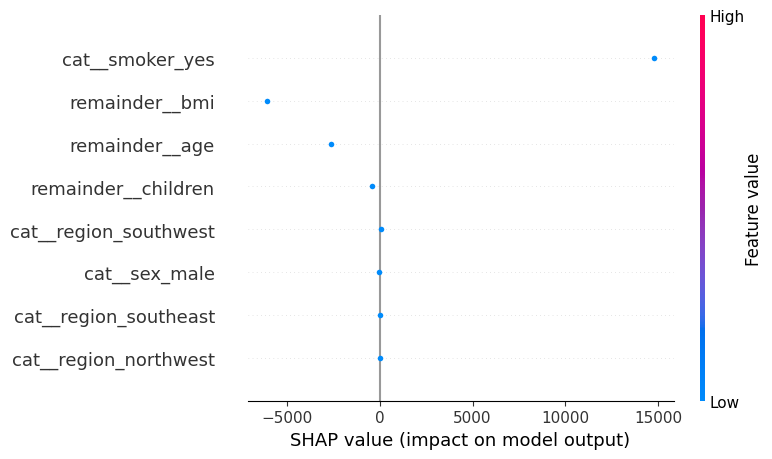

In [88]:
import shap
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    sample_encoded,
    feature_names=preprocessor_loaded.get_feature_names_out()
)

In [90]:
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    feature_names=preprocessor_loaded.get_feature_names_out()
)

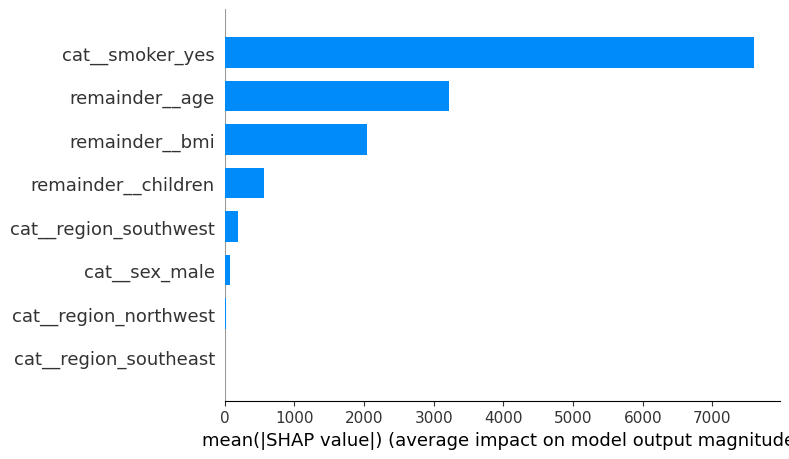

In [95]:
shap.summary_plot(
    shap_values,
    X_test_encoded,
    feature_names=preprocessor_loaded.get_feature_names_out(),
    plot_type="bar"
)

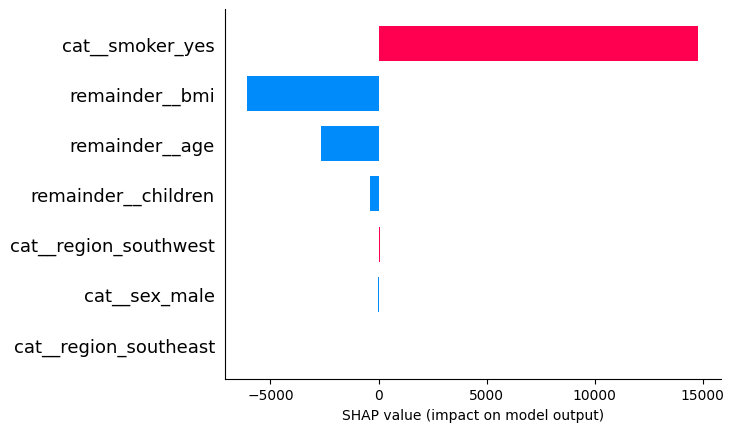

In [97]:
shap_values_sample = explainer.shap_values(sample_encoded)

shap.bar_plot(
    shap_values_sample[0],
    feature_names=preprocessor_loaded.get_feature_names_out()
)

## 9. Save Model Artifacts

Save the trained model and preprocessing pipeline for future deployment through an API or cloud service.

In [99]:
import joblib

joblib.dump(model, "xgboost_risk_model.pkl")
joblib.dump(preprocessor, "insurance_preprocessor.pkl")

print("✅ Model and preprocessor saved")

✅ Model and preprocessor saved
